In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from scipy.signal import wiener

# 1. Load sample leaf image from splits
split_csv = Path(r"C:\Users\HP\Desktop\projects\plantdiseaseprediction\data\dataset_splits.csv")
df = pd.read_csv(split_csv)

sample_path = df.iloc[0]["filepath"]
img_bgr = cv2.imread(sample_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

print(f"Loaded: {df.iloc[0]['class_name']} | Dimensions: {img_gray.shape}")

Loaded: Apple___Cedar_apple_rust | Dimensions: (256, 256)


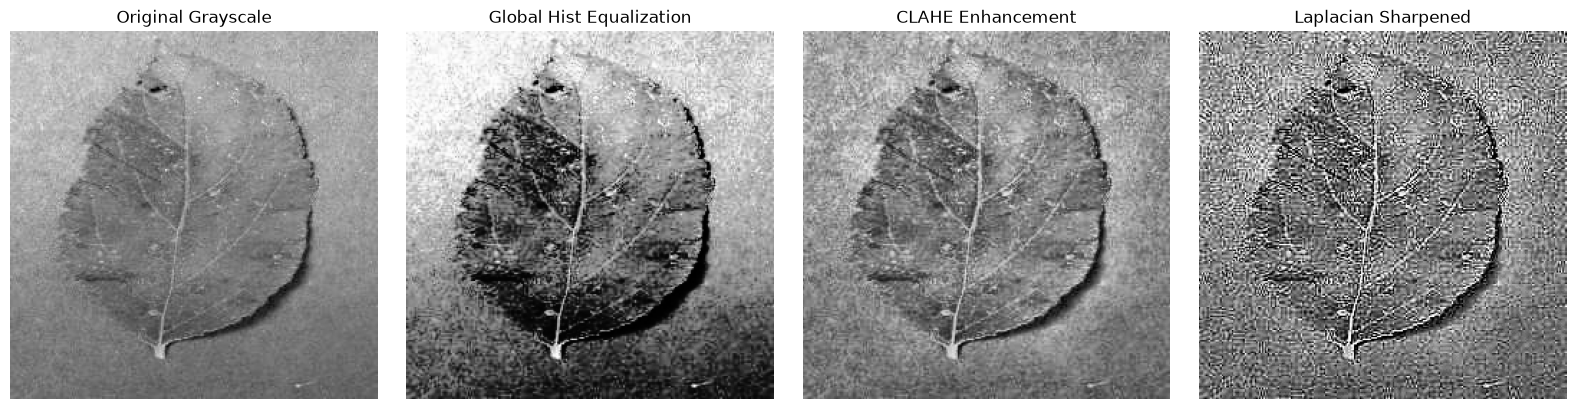

In [2]:
# Standard Histogram Equalization
hist_eq = cv2.equalizeHist(img_gray)

# CLAHE (Adaptive Histogram Equalization)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
img_clahe = clahe.apply(img_gray)

# Spatial Sharpening using Laplacian Kernel
laplacian_kernel = np.array([[0, -1, 0],
                             [-1, 5, -1],
                             [0, -1, 0]])
img_sharpened = cv2.filter2D(img_clahe, -1, laplacian_kernel)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(img_gray, cmap="gray")
axes[0].set_title("Original Grayscale")
axes[1].imshow(hist_eq, cmap="gray")
axes[1].set_title("Global Hist Equalization")
axes[2].imshow(img_clahe, cmap="gray")
axes[2].set_title("CLAHE Enhancement")
axes[3].imshow(img_sharpened, cmap="gray")
axes[3].set_title("Laplacian Sharpened")

for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

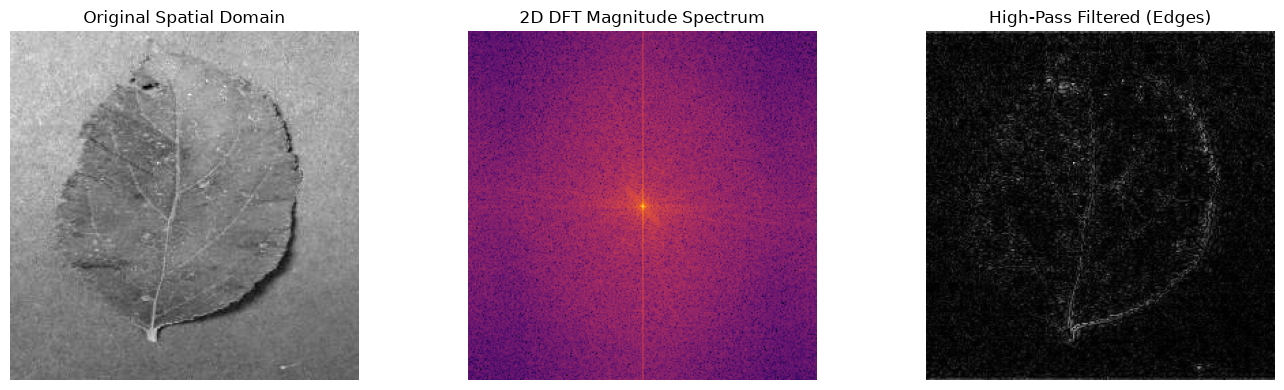

In [3]:
# Compute 2D Discrete Fourier Transform
dft = np.fft.fft2(img_gray)
dft_shift = np.fft.fftshift(dft)
magnitude_spectrum = 20 * np.log(np.abs(dft_shift) + 1)

# Construct Ideal High-Pass Filter (IHPF)
rows, cols = img_gray.shape
crow, ccol = rows // 2, cols // 2
radius = 30

mask_high_pass = np.ones((rows, cols), np.uint8)
y, x = np.ogrid[:rows, :cols]
mask_area = (x - ccol) ** 2 + (y - crow) ** 2 <= radius ** 2
mask_high_pass[mask_area] = 0

# Apply High-Pass Filter and compute Inverse 2D-DFT
fshift = dft_shift * mask_high_pass
f_ishift = np.fft.ifftshift(fshift)
img_back = np.fft.ifft2(f_ishift)
img_filtered = np.abs(img_back)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(img_gray, cmap="gray")
axes[0].set_title("Original Spatial Domain")
axes[1].imshow(magnitude_spectrum, cmap="inferno")
axes[1].set_title("2D DFT Magnitude Spectrum")
axes[2].imshow(img_filtered, cmap="gray")
axes[2].set_title("High-Pass Filtered (Edges)")

for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

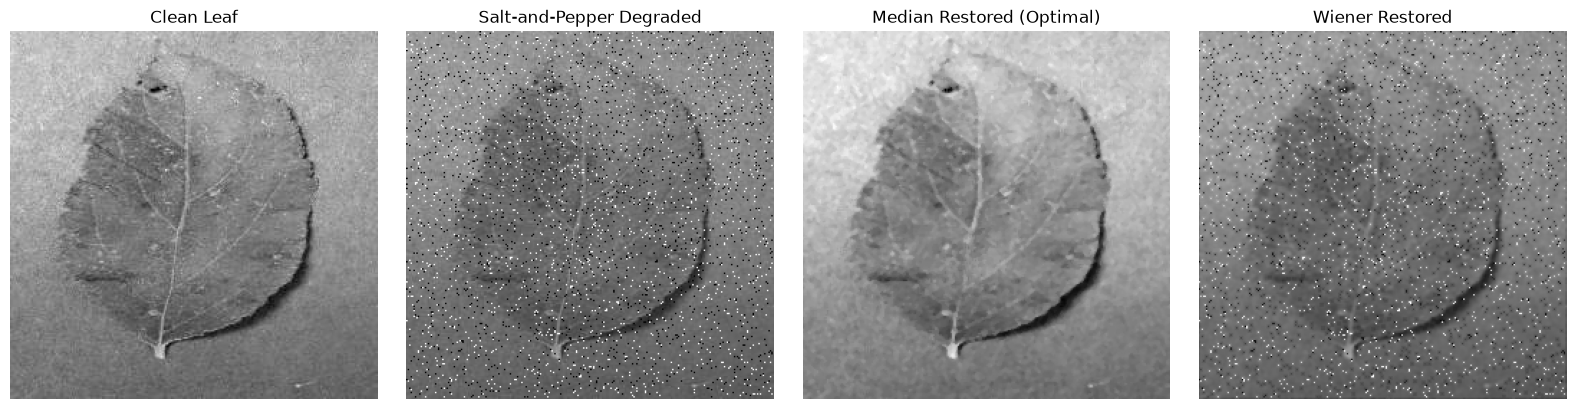

In [4]:
# Add Salt-and-Pepper Noise
noisy_img = img_gray.copy()
prob = 0.05
num_salt = np.ceil(prob * img_gray.size * 0.5)
num_pepper = np.ceil(prob * img_gray.size * 0.5)

# Salt (white pixels)
coords = [np.random.randint(0, i - 1, int(num_salt)) for i in img_gray.shape]
noisy_img[tuple(coords)] = 255

# Pepper (black pixels)
coords = [np.random.randint(0, i - 1, int(num_pepper)) for i in img_gray.shape]
noisy_img[tuple(coords)] = 0

# Spatial Restoration: Median Filter
restored_median = cv2.medianBlur(noisy_img, 3)

# Wiener Filter Restoration
restored_wiener = wiener(noisy_img.astype(np.float64), (3, 3))
restored_wiener = np.clip(restored_wiener, 0, 255).astype(np.uint8)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(img_gray, cmap="gray")
axes[0].set_title("Clean Leaf")
axes[1].imshow(noisy_img, cmap="gray")
axes[1].set_title("Salt-and-Pepper Degraded")
axes[2].imshow(restored_median, cmap="gray")
axes[2].set_title("Median Restored (Optimal)")
axes[3].imshow(restored_wiener, cmap="gray")
axes[3].set_title("Wiener Restored")

for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

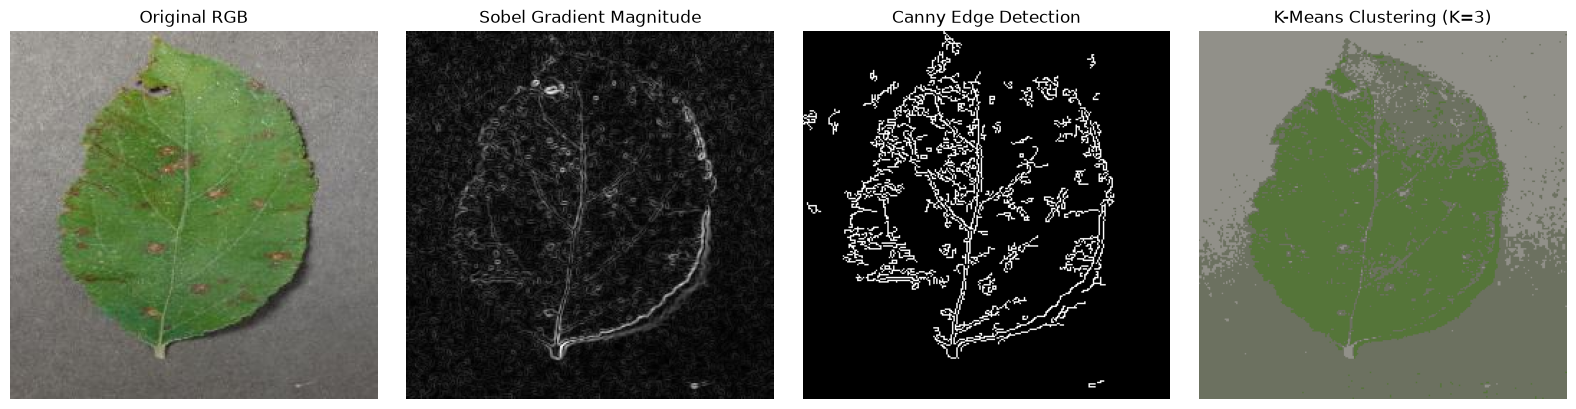

In [5]:
# 1. Edge Detection (Sobel & Canny)
sobel_x = cv2.Sobel(img_gray, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(img_gray, cv2.CV_64F, 0, 1, ksize=3)
sobel_combined = cv2.magnitude(sobel_x, sobel_y)
canny_edges = cv2.Canny(img_gray, 50, 150)

# 2. Region Segmentation by Clustering (K-Means, K=3)
pixel_values = img_rgb.reshape((-1, 3)).astype(np.float32)
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
k = 3
_, labels, centers = cv2.kmeans(pixel_values, k, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
centers = np.uint8(centers)
segmented_kmeans = centers[labels.flatten()].reshape(img_rgb.shape)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(img_rgb)
axes[0].set_title("Original RGB")
axes[1].imshow(sobel_combined, cmap="gray")
axes[1].set_title("Sobel Gradient Magnitude")
axes[2].imshow(canny_edges, cmap="gray")
axes[2].set_title("Canny Edge Detection")
axes[3].imshow(segmented_kmeans)
axes[3].set_title("K-Means Clustering (K=3)")

for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

In [6]:
# Generate binary mask via Otsu
_, binary_leaf = cv2.threshold(img_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
flat_pixels = (binary_leaf.flatten() > 0).astype(int)

# Compute Run-Length Encoding (RLE)
runs = []
prev = flat_pixels[0]
count = 0

for pixel in flat_pixels:
    if pixel == prev:
        count += 1
    else:
        runs.append((prev, count))
        prev = pixel
        count = 1
runs.append((prev, count))

# Calculate storage footprint and compression ratio
original_bits = len(flat_pixels) * 8
compressed_bits = len(runs) * (8 + 16) # 8 bits for value, 16 bits for run length
compression_ratio = original_bits / compressed_bits

print("=== Image Compression Benchmark (Lossless RLE) ===")
print(f"Original Mask Size:    {original_bits / 8:.0f} bytes")
print(f"Compressed Size (RLE): {compressed_bits / 8:.0f} bytes")
print(f"Compression Ratio:     {compression_ratio:.2f} : 1")

=== Image Compression Benchmark (Lossless RLE) ===
Original Mask Size:    65536 bytes
Compressed Size (RLE): 11208 bytes
Compression Ratio:     5.85 : 1
